# Iris Flower Classification Using Machine Learning

## Import Required Libraries

In [4]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Import csv file(dataset)

In [5]:

df = pd.read_csv(r"C:\Users\bhanu\OneDrive\Desktop\OIBSIP\DataScience-Task1-IrisFlowerClassification\Iris.csv")


df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Check Dataset Shape

In [6]:

df.shape #(rows,columns)

(150, 6)

## Display Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## Statistical Summary 

In [8]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## Column Names

In [9]:
df.columns


Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

## checking Missing Values 

In [10]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

#### The dataset does not contain missing values, so no missing value treatment is required.


## Check Species Count

In [11]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## Drop Unnecessary Column

In [12]:
df = df.drop("Id", axis=1) 

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Visualize Species Count (Countplot)

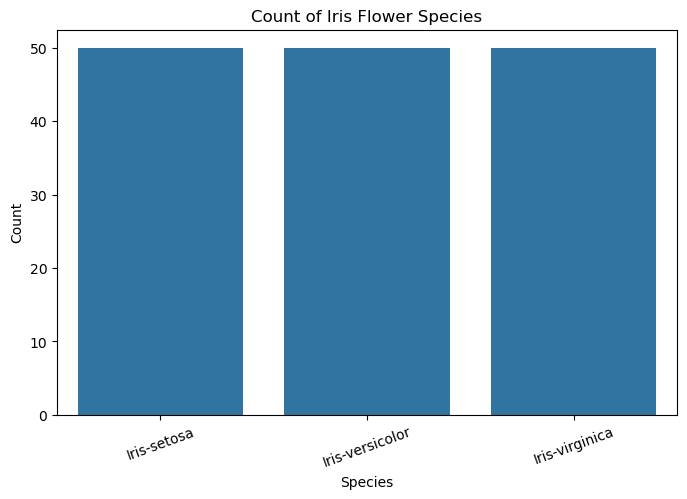

In [13]:

# Countplot of species
plt.figure(figsize=(8,5))

sns.countplot(x="Species", data=df)

plt.title("Count of Iris Flower Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.xticks(rotation=20)
plt.show()

## Pairplot Visualization (to understand relationship between features)

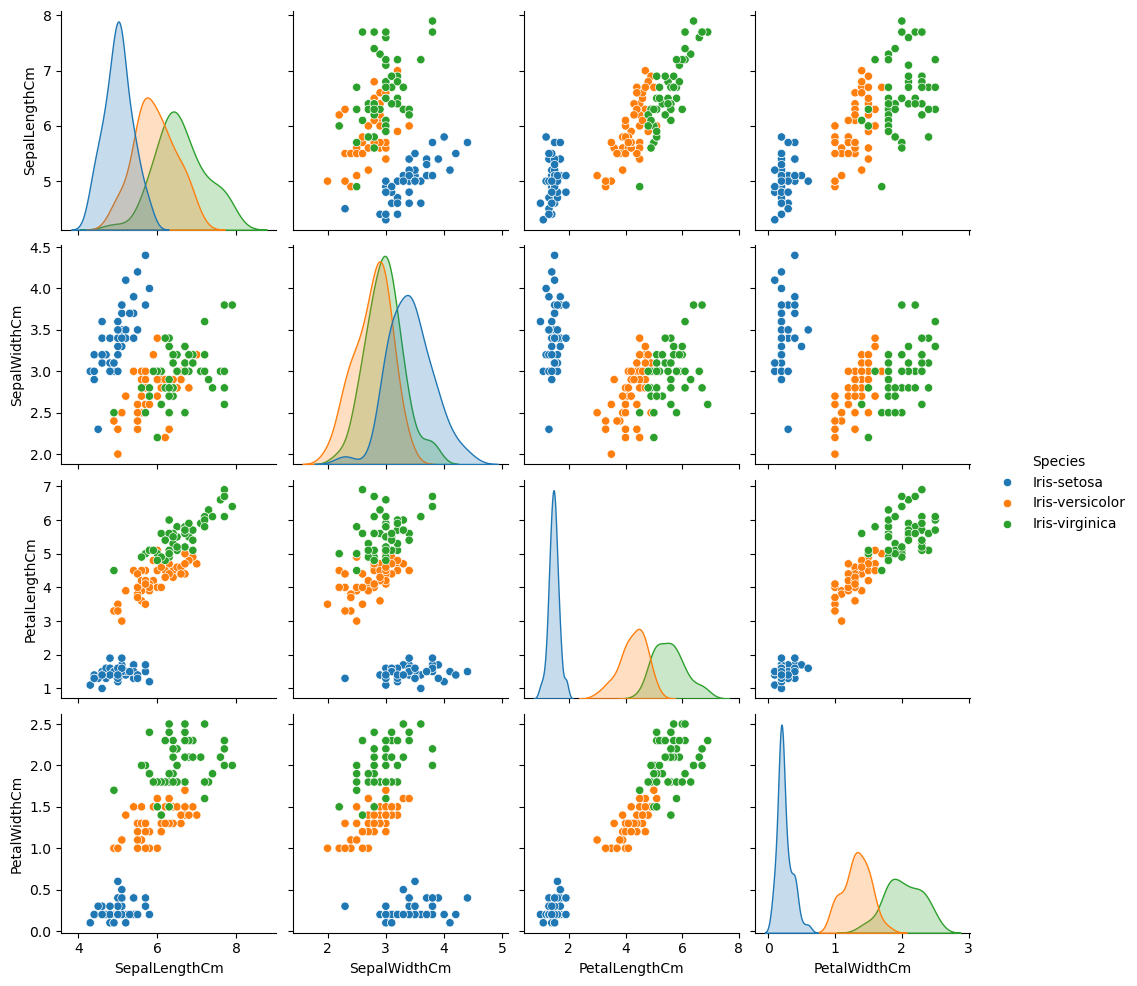

In [14]:
sns.pairplot(df, hue="Species")
plt.show()

## Correlation heatmap

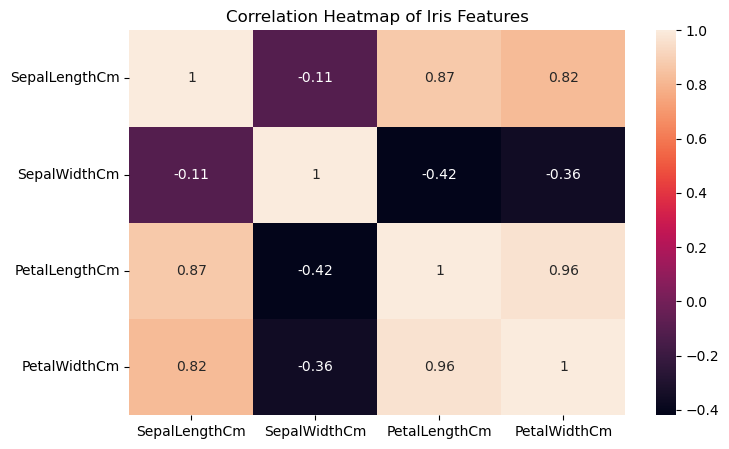

In [15]:

plt.figure(figsize=(8,5))
sns.heatmap(df.drop("Species", axis=1).corr(), annot=True)
plt.title("Correlation Heatmap of Iris Features")
plt.show()

## Prepare Features and Target 

In [16]:

X = df.drop("Species", axis=1)


y = df["Species"]

## Encode Target Variable

In [17]:

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


label_encoder.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

## Split Dataset into Training and Testing Data

In [18]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


## Train the Machine Learning Model (Random Forest)

In [19]:

model = RandomForestClassifier(random_state=42)


model.fit(X_train, y_train) 

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Make Predictions 

In [20]:

y_pred = model.predict(X_test)


y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

## Check Model Accuracy

In [21]:

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


## Classification Report

In [22]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



## Confusion Matrix

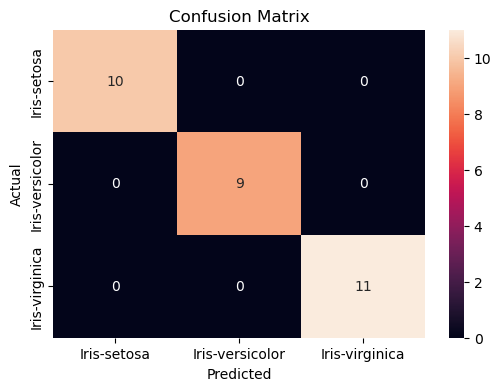

In [23]:

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Test with Custom Input

In [24]:

sample = [[5.1, 3.5, 1.4, 0.2]]


prediction = model.predict(sample)

predicted_species = label_encoder.inverse_transform(prediction)

print("Predicted Species:", predicted_species[0])

Predicted Species: Iris-setosa


C:\Users\bhanu\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Box Plot Visualization

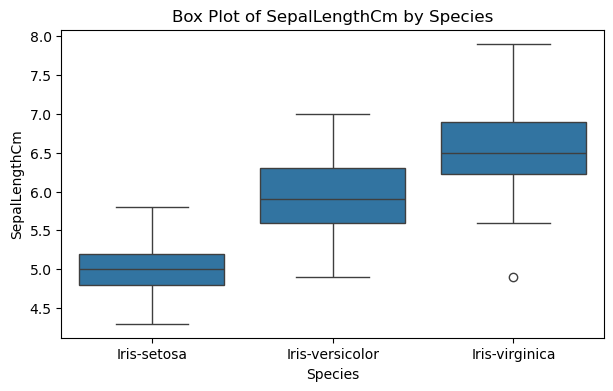

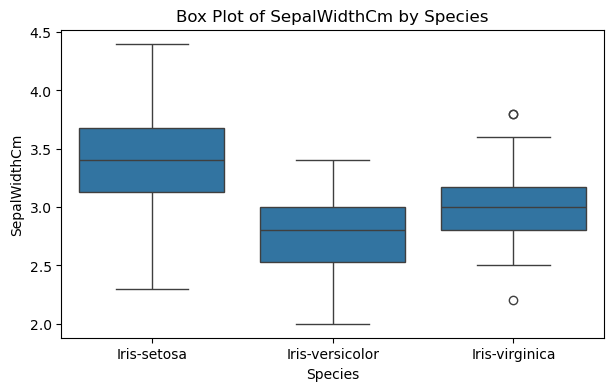

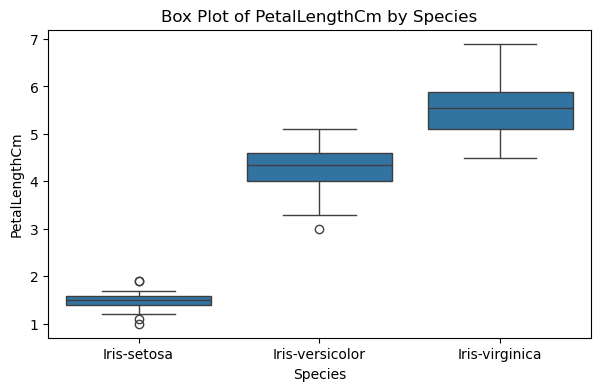

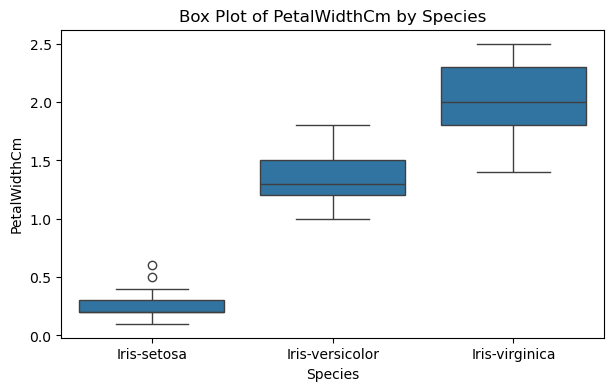

In [25]:
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

for feature in features:
    plt.figure(figsize=(7,4))
    sns.boxplot(x="Species", y=feature, data=df)
    plt.title(f"Box Plot of {feature} by Species")
    plt.xlabel("Species")
    plt.ylabel(feature)
    plt.show()

 The box plots show how each feature is distributed across the three Iris species. PetalLengthCm and PetalWidthCm show clearer separation between the species compared to sepal features. This indicates that petal measurements are more useful for classifying Iris flowers.

## Feature Selection Discussion

From the visualizations, PetalLengthCm and PetalWidthCm appear to be the most discriminative features for classifying Iris flowers. Iris-setosa is clearly separated from the other species using petal measurements. Iris-versicolor and Iris-virginica have some overlap, but petal length and petal width still provide better separation than sepal length and sepal width.

SepalLengthCm and SepalWidthCm are useful, but they show more overlap between species. Therefore, all four features were used for model training, but petal length and petal width are the strongest features for classification.

## Training Multiple Machine Learning Models

In [26]:
# Import additional classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Create different classification models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Train and evaluate each model
model_results = {}

for model_name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_model = model.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred_model)
    model_results[model_name] = accuracy
    
    print("Model:", model_name)
    print("Accuracy:", accuracy)
    print("Classification Report:")
    print(classification_report(y_test, y_pred_model, target_names=label_encoder.classes_))
    print("-" * 60)

Model: Logistic Regression
Accuracy: 1.0
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

------------------------------------------------------------
Model: K-Nearest Neighbors
Accuracy: 1.0
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

-------

The model accuracy comparison shows that all four classification models achieved an accuracy of 1.0 on the test dataset. This means Logistic Regression, K-Nearest Neighbors, Decision Tree, and Random Forest correctly classified all test samples.

Since the Iris dataset is clean, balanced, and has clear feature patterns, especially in petal length and petal width, all models performed very well. The classification reports also show precision, recall, and F1-score values of 1.00 for all three species.

## Model Comparison

In [27]:

results_df = pd.DataFrame({
    "Model": model_results.keys(),
    "Accuracy": model_results.values()
})

results_df

,Model,Accuracy
0,Logistic Regression,1.0
1,K-Nearest Neighbors,1.0
2,Decision Tree,1.0
3,Random Forest,1.0


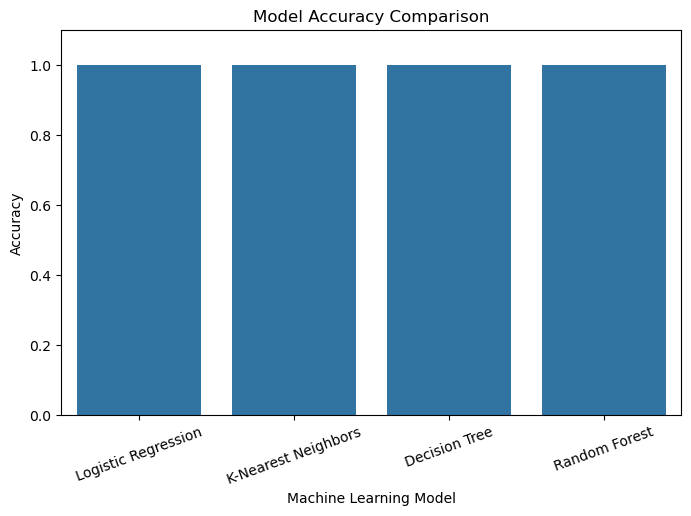

In [28]:

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1.1)
plt.show()

## Best Model Selection

In [29]:
best_model_name = max(model_results, key=model_results.get)
best_accuracy = model_results[best_model_name]

print("Best Performing Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Performing Model: Logistic Regression
Best Accuracy: 1.0


## Best Model Justification

After training and evaluating four classification models, Logistic Regression was selected as the best-performing model because it achieved an accuracy of 1.0 on the test dataset.

Although K-Nearest Neighbors, Decision Tree, and Random Forest also achieved the same accuracy, Logistic Regression was selected because it is simple, easy to interpret, and performs very well on clean classification datasets like the Iris dataset.

The Iris dataset has clear separation between species, especially using petal length and petal width. Because of this, Logistic Regression was able to classify all test samples correctly.

Therefore, Logistic Regression was considered the final model for this project.